### ML analysis from data collected from model_processing_v3 notebook

In [27]:
#import statements
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import nilearn.image
import nilearn.plotting
import copy
from torch.utils.data import random_split
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from pathlib import Path
import ants
import pydicom
import nibabel as nib
import os
from glob import glob
from tqdm import tqdm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchinfo import summary
import nilearn

In [28]:
# --- Load cohort CSV --------------------------------------------------------
DATA = Path("model_data/adni")
FULL = DATA / "dti_t1_full_data"

meta = pd.read_csv(FULL / "paired_df_combined.csv")

MODALITIES = ["t1_gm", "t1_wm", "t1_csf", "dti_gm", "dti_wm", "dti_csf"]

In [5]:
key_col = {
    "t1_gm":  "t1_image_subject_id",
    "t1_wm":  "t1_image_subject_id",
    "t1_csf": "t1_image_subject_id",
    "dti_gm":  "dti_image_subject_id",
    "dti_wm":  "dti_image_subject_id",
    "dti_csf": "dti_image_subject_id",
}
parquet_paths = {
    "t1_gm":  FULL / "full_masked_gm_t1.parquet",
    "t1_wm":  FULL / "full_masked_wm_t1.parquet",
    "t1_csf": FULL / "full_masked_csf_t1.parquet",
    "dti_gm":  FULL / "full_masked_gm_dti.parquet",
    "dti_wm":  FULL / "full_masked_wm_dti.parquet",
    "dti_csf": FULL / "full_masked_csf_dti.parquet",
}

X_raw = {
    k: pd.read_parquet(p).loc[meta[key_col[k]]].values.astype(np.float32)
    for k, p in parquet_paths.items()
}

In [19]:
# Create four groups based on CN/Impaired and amyloid_label
# "Impaired" = MCI + Dementia
impaired_mask = meta['group'].isin(['MCI', 'Dementia'])

cn_amyloid_1       = meta[(meta['group'] == 'CN') & (meta['amyloid_label'] == 1.0)]
cn_amyloid_0       = meta[(meta['group'] == 'CN') & (meta['amyloid_label'] == 0.0)]
impaired_amyloid_1 = meta[impaired_mask             & (meta['amyloid_label'] == 1.0)]
impaired_amyloid_0 = meta[impaired_mask             & (meta['amyloid_label'] == 0.0)]

In [20]:
# Create StandardScaler on CN group for each modality and apply to MCI and Dementia groups
scalers = {}
X_scaled = {}

cn_mask     = meta["group"].eq("CN").values
mci_dem_mask = meta["group"].isin(["MCI", "Dementia"]).values

for modality in MODALITIES:
    X_mod = X_raw[modality].astype(np.float32)
    scaler = StandardScaler().fit(X_mod[cn_mask])
    scalers[modality] = scaler
    X_scaled[modality] = scaler.transform(X_mod[mci_dem_mask]).astype(np.float32)

In [21]:
# Scree + balanced-accuracy sweep (1–50 PCs) per modality — 4-class task
# Classes: 0=CN_amy0, 1=CN_amy1, 2=Impaired_amy0, 3=Impaired_amy1
# "Impaired" = MCI + Dementia

from sklearn.model_selection import StratifiedGroupKFold

amy_mask = (
    meta["group"].isin(["CN", "MCI", "Dementia"]) &
    meta["amyloid_label"].notna()
).values

g4_raw = meta.loc[amy_mask, "group"].values
g4 = np.where(np.isin(g4_raw, ["MCI", "Dementia"]), "Impaired", g4_raw)
a4 = meta.loc[amy_mask, "amyloid_label"].values.astype(int)

label_map_4 = {("CN", 0): 0, ("CN", 1): 1, ("Impaired", 0): 2, ("Impaired", 1): 3}
y4 = np.array([label_map_4[(g, a)] for g, a in zip(g4, a4)], dtype=np.int64)

idx4    = np.where(amy_mask)[0]
groups4 = meta.loc[amy_mask, "subject_id"].values

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
local_idx = np.arange(len(y4))
local_tr, local_te = next(sgkf.split(local_idx, y4, groups=groups4))

y4_tr, y4_te = y4[local_tr], y4[local_te]

assert len(set(groups4[local_tr]) & set(groups4[local_te])) == 0, "Subject leakage!"

print(f"4-class split: total={len(y4)}  train={len(local_tr)}  test={len(local_te)}")
print(f"Unique subjects — train: {len(set(groups4[local_tr]))}  test: {len(set(groups4[local_te]))}")
for cls, name in enumerate(["CN_amy0", "CN_amy1", "Impaired_amy0", "Impaired_amy1"]):
    print(f"  class {cls} ({name}): {(y4 == cls).sum()}")

4-class split: total=802  train=649  test=153
Unique subjects — train: 413  test: 104
  class 0 (CN_amy0): 236
  class 1 (CN_amy1): 198
  class 2 (Impaired_amy0): 159
  class 3 (Impaired_amy1): 209


In [22]:
# --- Sweep 1–50 PCs ---
PC_RANGE = list(range(1, 51))
scree_records, bacc_records = [], []

for mod in MODALITIES:
    X_full = scalers[mod].transform(X_raw[mod].astype(np.float32))
    X4     = X_full[idx4]
    X4_tr  = X4[local_tr]
    X4_te  = X4[local_te]

    pca_full = PCA(n_components=50, random_state=0, svd_solver="randomized").fit(X4_tr)
    evr = pca_full.explained_variance_ratio_
    Z_tr_full = pca_full.transform(X4_tr)
    Z_te_full = pca_full.transform(X4_te)

    for n_pc in PC_RANGE:
        scree_records.append({"modality": mod, "n_pc": n_pc,
                               "var_explained": float(evr[n_pc - 1])})
        clf  = SVC(class_weight="balanced", random_state=0,
                   decision_function_shape="ovr").fit(Z_tr_full[:, :n_pc], y4_tr)
        bacc = balanced_accuracy_score(y4_te, clf.predict(Z_te_full[:, :n_pc]))
        bacc_records.append({"modality": mod, "n_pc": n_pc, "bAcc": float(bacc)})

    print(f"  {mod} done")

scree_df = pd.DataFrame(scree_records)
bacc_df  = pd.DataFrame(bacc_records)

  t1_gm done
  t1_wm done
  t1_csf done
  dti_gm done
  dti_wm done
  dti_csf done


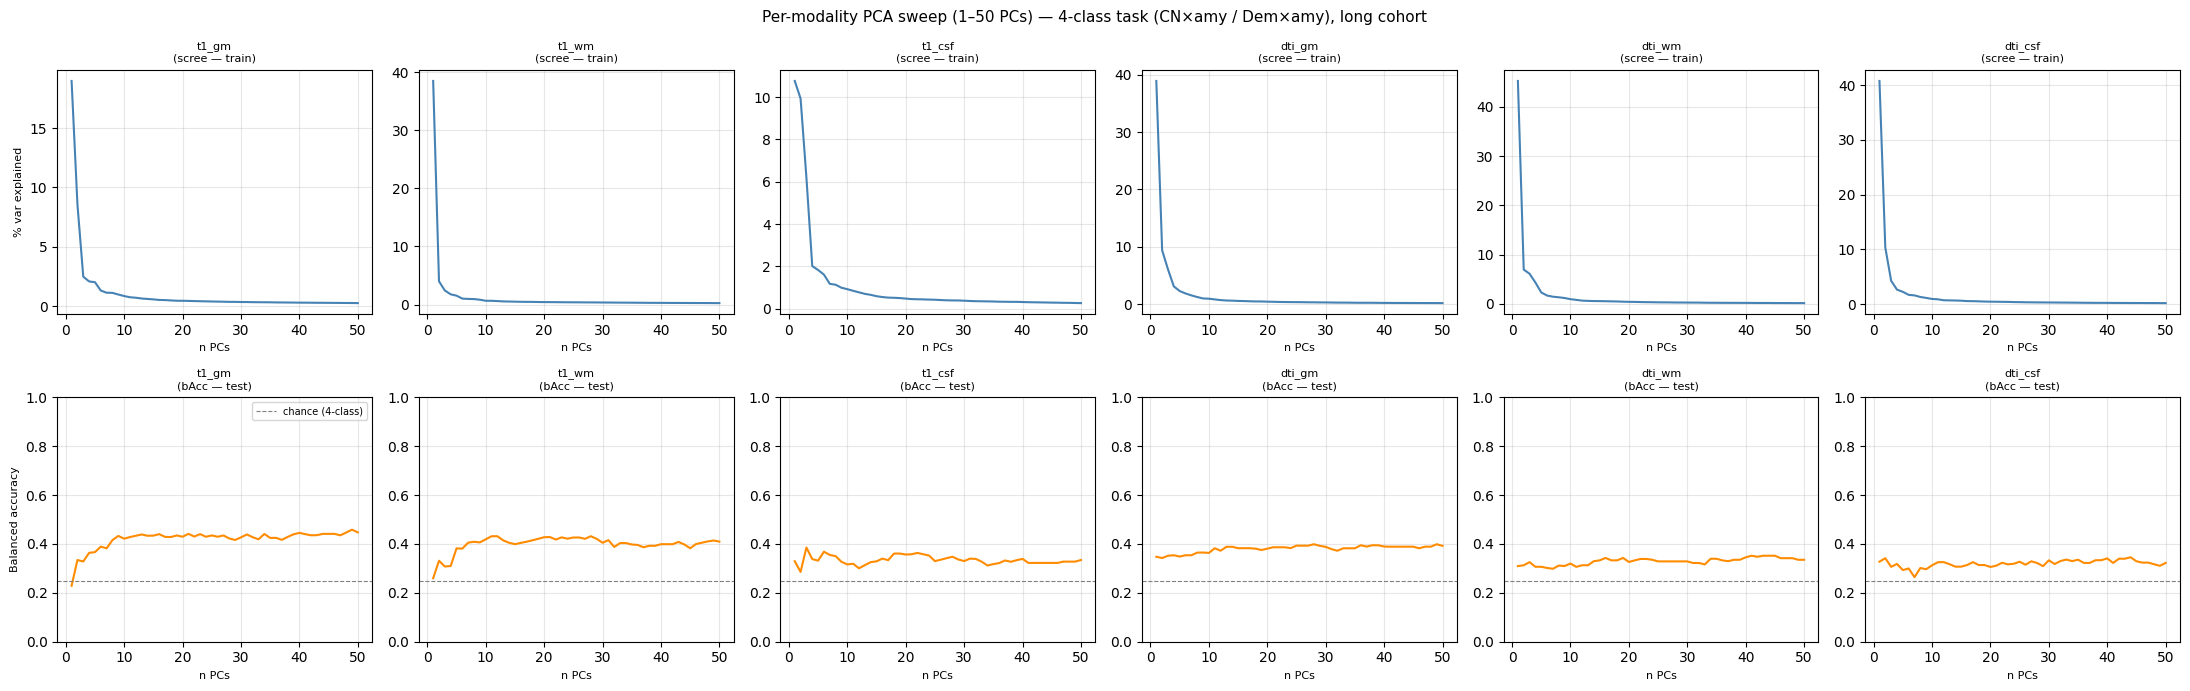

In [23]:
# --- 2×6 plot grid ---
fig, axes = plt.subplots(2, 6, figsize=(22, 7))

for col, mod in enumerate(MODALITIES):
    sub_s = scree_df[scree_df["modality"] == mod]
    sub_b = bacc_df[bacc_df["modality"]  == mod]

    ax_s = axes[0, col]
    ax_s.plot(sub_s["n_pc"], sub_s["var_explained"] * 100, color="steelblue", lw=1.5)
    ax_s.set_title(f"{mod}\n(scree — train)", fontsize=8)
    ax_s.set_xlabel("n PCs", fontsize=8)
    ax_s.set_ylabel("% var explained" if col == 0 else "", fontsize=8)
    ax_s.grid(True, alpha=0.3)

    ax_b = axes[1, col]
    ax_b.plot(sub_b["n_pc"], sub_b["bAcc"], color="darkorange", lw=1.5)
    ax_b.axhline(0.25, color="grey", lw=0.8, ls="--", label="chance (4-class)")
    ax_b.set_xlabel("n PCs", fontsize=8)
    ax_b.set_ylabel("Balanced accuracy" if col == 0 else "", fontsize=8)
    ax_b.set_title(f"{mod}\n(bAcc — test)", fontsize=8)
    ax_b.set_ylim(0, 1)
    ax_b.grid(True, alpha=0.3)
    if col == 0:
        ax_b.legend(fontsize=7)

fig.suptitle(
    "Per-modality PCA sweep (1–50 PCs) — 4-class task (CN×amy / Dem×amy), long cohort",
    fontsize=11
)
plt.tight_layout()
plt.show()

In [30]:
# CN vs MCI+Dementia: balanced SVM with 15 PCs per modality
# y = diag_label (0=CN, 1=MCI/Dementia)
from sklearn.model_selection import StratifiedGroupKFold

N_PC = 15

y_bin      = meta["specific_diag"].values
groups_bin = meta["subject_id"].values

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
tr, te = next(sgkf.split(np.arange(len(y_bin)), y_bin, groups=groups_bin))
y_tr, y_te = y_bin[tr], y_bin[te]

print(f"Train: CN={(y_tr==0).sum()}  Impaired={(y_tr==1).sum()}")
print(f"Test:  CN={(y_te==0).sum()}  Impaired={(y_te==1).sum()}")
print()
print(f"{'Modality':<12}  {'bAcc':>6}  {'Sens':>6}  {'Spec':>6}")
print("-" * 38)

for mod in MODALITIES:
    Xs = scalers[mod].transform(X_raw[mod])
    X_tr, X_te = Xs[tr], Xs[te]

    pca  = PCA(n_components=N_PC, random_state=0, svd_solver="randomized").fit(X_tr)
    Z_tr = pca.transform(X_tr)
    Z_te = pca.transform(X_te)

    clf    = SVC(class_weight="balanced", random_state=0).fit(Z_tr, y_tr)
    y_pred = clf.predict(Z_te)

    bacc = balanced_accuracy_score(y_te, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_te, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) else float("nan")
    spec = tn / (tn + fp) if (tn + fp) else float("nan")

    print(f"{mod:<12}  {bacc:>6.3f}  {sens:>6.3f}  {spec:>6.3f}")

Train: CN=442  Impaired=203
Test:  CN=105  Impaired=52

Modality        bAcc    Sens    Spec
--------------------------------------
t1_gm          0.539   0.250   0.829
t1_wm          0.602   0.327   0.876
t1_csf         0.593   0.481   0.705
dti_gm         0.559   0.423   0.695
dti_wm         0.559   0.385   0.733
dti_csf        0.588   0.519   0.657


In [25]:
# Amyloid +/- prediction: balanced SVM with 15 PCs per modality
amy_valid = meta["amyloid_label"].notna().values
y_amy     = meta.loc[amy_valid, "amyloid_label"].astype(int).values
groups_amy = meta.loc[amy_valid, "subject_id"].values
idx_amy   = np.where(amy_valid)[0]

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
tr, te = next(sgkf.split(np.arange(len(y_amy)), y_amy, groups=groups_amy))
y_tr, y_te = y_amy[tr], y_amy[te]

print(f"Train: amy-={(y_tr==0).sum()}  amy+={(y_tr==1).sum()}")
print(f"Test:  amy-={(y_te==0).sum()}  amy+={(y_te==1).sum()}")
print()
print(f"{'Modality':<12}  {'bAcc':>6}  {'Sens+':>6}  {'Spec-':>6}")
print("-" * 38)

for mod in MODALITIES:
    Xs   = scalers[mod].transform(X_raw[mod])
    Xsub = Xs[idx_amy]
    X_tr, X_te = Xsub[tr], Xsub[te]

    pca  = PCA(n_components=N_PC, random_state=0, svd_solver="randomized").fit(X_tr)
    Z_tr = pca.transform(X_tr)
    Z_te = pca.transform(X_te)

    clf    = SVC(class_weight="balanced", random_state=0).fit(Z_tr, y_tr)
    y_pred = clf.predict(Z_te)

    bacc = balanced_accuracy_score(y_te, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_te, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) else float("nan")
    spec = tn / (tn + fp) if (tn + fp) else float("nan")

    print(f"{mod:<12}  {bacc:>6.3f}  {sens:>6.3f}  {spec:>6.3f}")

Train: amy-=314  amy+=329
Test:  amy-=81  amy+=78

Modality        bAcc   Sens+   Spec-
--------------------------------------
t1_gm          0.555   0.654   0.457
t1_wm          0.523   0.590   0.457
t1_csf         0.531   0.654   0.407
dti_gm         0.517   0.564   0.469
dti_wm         0.490   0.436   0.543
dti_csf        0.467   0.526   0.407
